### Imports

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, SplineTransformer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
from pygam import LinearGAM, s

### Data Generation

In [29]:
# Define the true function we want the models to learn
def true_function(x):
    return np.sin(x * np.pi) + np.cos(x * 1.5 * np.pi)


# Generate the data
np.random.seed(42)
n_samples = 100
X = np.sort(np.random.rand(n_samples) * 3)
y = true_function(X) + np.random.randn(n_samples) * 0.3

# Prepare test data for visualization of the fitted curve
X_test = np.linspace(0, 3, 500)
y_true = true_function(X_test)

# Put the data in the correct format for the models
X = X[:, np.newaxis]
X_test = X_test[:, np.newaxis]

### Polynomial Regression

In [21]:
# Create a pipeline that first adds polynomial features and then fits a linear model
poly_degree = 12
poly_model = make_pipeline(
    PolynomialFeatures(degree=poly_degree, include_bias=False), LinearRegression()
)
poly_model.fit(X, y)
y_poly_pred = poly_model.predict(X_test)
mse_poly = mean_squared_error(true_function(X), poly_model.predict(X))

print(f"Degree of the Polynomial: {poly_degree}")
print(f"MSE (Polinomial): {mse_poly:.4f}\n")

Degree of the Polynomial: 12
MSE (Polinomial): 0.0067



### Regression with Splines

In [22]:
# Creates a pipeline with a spline transformer (B-splines) and a linear model
# n_knots controls the number of "knots" or junction points, increasing flexibility
spline_model = make_pipeline(SplineTransformer(n_knots=8, degree=3), LinearRegression())
spline_model.fit(X, y)
y_spline_pred = spline_model.predict(X_test)
mse_spline = mean_squared_error(true_function(X), spline_model.predict(X))

print(f"Number of Knots: {spline_model.named_steps['splinetransformer'].n_knots}")
print(f"MSE (Splines): {mse_spline:.4f}\n")

Number of Knots: 8
MSE (Splines): 0.0042



### Generalized Additive Model (GAM)

In [23]:
# GAM automatically finds the optimal smoothness for the spline function
# s(0) indicates a smoothing function (spline) for the first (and only) feature
# n_splines defines the number of base splines for optimization
gam_model = LinearGAM(s(0, n_splines=20)).fit(X, y)
y_gam_pred = gam_model.predict(X_test)
mse_gam = mean_squared_error(true_function(X), gam_model.predict(X))

print(f"Number of Base Splines: 20")
print(f"MSE (GAM): {mse_gam:.4f}\n")

Number of Base Splines: 20
MSE (GAM): 0.0035



### Plot

Final Comparison of Mean Squared Errors (MSE):
  - Polynomial Regression: 0.0067
  - Regression with Splines: 0.0042
  - Generalized Additive Model (GAM): 0.0035


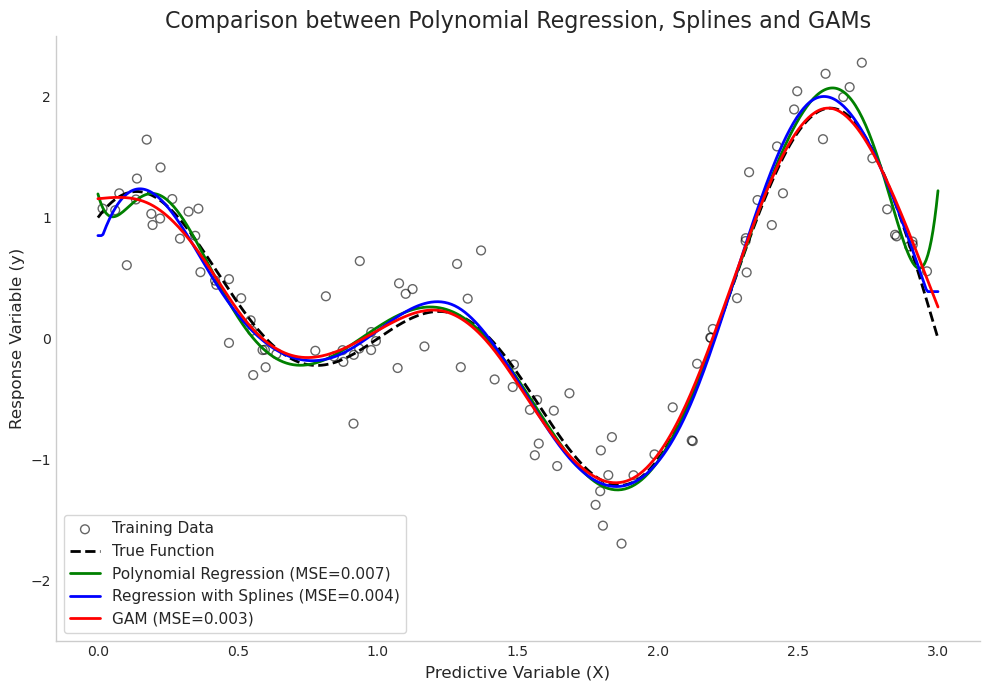

In [24]:
plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(10, 7))

# Original data
plt.scatter(
    X, y, s=40, facecolors="none", edgecolors="k", alpha=0.6, label="Training Data"
)

# True function
plt.plot(X_test, y_true, "k--", lw=2, label="True Function")

# Model predictions
plt.plot(
    X_test, y_poly_pred, "g", lw=2, label=f"Polynomial Regression (MSE={mse_poly:.3f})"
)
plt.plot(
    X_test,
    y_spline_pred,
    "b",
    lw=2,
    label=f"Regression with Splines (MSE={mse_spline:.3f})",
)
plt.plot(X_test, y_gam_pred, "r", lw=2, label=f"GAM (MSE={mse_gam:.3f})")

# Chart Settings
plt.title("Comparison between Polynomial Regression, Splines and GAMs", fontsize=16)
plt.xlabel("Predictive Variable (X)", fontsize=12)
plt.ylabel("Response Variable (y)", fontsize=12)
plt.ylim(-2.5, 2.5)
plt.legend(frameon=True, fontsize=11)
plt.grid(False)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

print("Final Comparison of Mean Squared Errors (MSE):")
print(f"  - Polynomial Regression: {mse_poly:.4f}")
print(f"  - Regression with Splines: {mse_spline:.4f}")
print(f"  - Generalized Additive Model (GAM): {mse_gam:.4f}")